# 반도체 공정 스케줄링 시뮬레이션 결과 비교

## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from itertools import product
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
DOWN_TIME_UNIT = os.getenv('DOWN_TIME_UNIT', 'M')
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
print(f"DOWN_TIME_UNIT: {DOWN_TIME_UNIT}")

BASE_DATA_PATH: data/small_data
PM_HAZARD_THRESHOLD: 0.2
PM_ACTIVE: True
DOWN_ACTIVE: True
DOWN_TIME_UNIT: H

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

Jobs: 10 개 / Operations: 35 개 / Machines: 8 개

## 룰 비교 함수 정의

In [4]:
def run_simulation(machine_rule, job_rule, pm_rule):
    env = simpy.Environment()
    logger = EventLogger(env)

    os.environ['MACHINE_RULE'] = machine_rule
    os.environ['JOB_RULE'] = job_rule
    os.environ['PM_RULE'] = pm_rule
    scheduler = Scheduler(
        env=env,
        data=data,
        event_logger=logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD)
    )
    env.run(until=scheduler.job_chk_process)
    return logger.logs

## 룰별 N회 시뮬레이션 평균 비교

In [5]:
N_RUNS = 50
MACHINE_RULES = [
    'SPTSSU'
]
JOB_RULES = [
    'random',
    'FIFO',
    'SPT',
    'LPT',
    'MIN_QTIME',
    'SPTSSU'
]
PM_RULES = [
    'THRESHOLD'
]

metrics = []
seed = time.time()
for (machine_rule, job_rule, pm_rule, idx) in product(MACHINE_RULES, JOB_RULES, PM_RULES, range(N_RUNS)):
    random.seed(hash((seed, idx)))
    logs = run_simulation(machine_rule, job_rule, pm_rule)
    log = pd.DataFrame(logs)
    job_log = log[log['resource'] == 'job']
    machine_log = log[log['resource'] == 'machine']

    makespan = job_log.groupby('id')['finish'].max().max()
    flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
    job_type_map = data['jobs'].set_index('job_id')['job_type']
    flowtime = flowtime.to_frame(name='flowtime').join(job_type_map, on='id')
    flowtime = flowtime.groupby('job_type')['flowtime'].mean()

    completed = job_log.groupby('id')['finish'].max()
    job_duetime_map = data['jobs'].set_index('job_id')['due_date']
    tardiness = completed.to_frame(name='completed').join(job_duetime_map, on='id')
    tardiness = (tardiness['completed'] - tardiness['due_date']).apply(lambda x: max(x, 0)).to_frame(name='tardiness')
    tardiness = tardiness.join(job_type_map, on='id')
    tardiness = tardiness.groupby('job_type')['tardiness'].mean()

    qtime_violations = job_log[job_log['event'] == 'qtime_over']
    qtime_violations = sum(qtime_violations['finish'] - qtime_violations['start'])
    n_pm = len(machine_log[machine_log['event'] == 'PM'])
    n_repairs = len(machine_log[machine_log['event'] == 'repairing'])

    utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (x['finish'] - x['start']).sum() / makespan)
    machine_group_map = data['machines'].set_index('machine_id')['machine_group']
    utilization = utilization.to_frame(name='utilization').join(machine_group_map, on='id')
    utilization = utilization.groupby('machine_group')['utilization'].mean()

    metrics.append({
        'machine_rule': machine_rule,
        'job_rule': job_rule,
        'pm_rule': pm_rule,
        'try': idx + 1,
        'makespan': makespan,
        'flowtime': flowtime,
        'tardiness': tardiness,
        'qtime_violations': qtime_violations,
        'n_pm': n_pm,
        'n_repairs': n_repairs,
        'utilization': utilization
    })
metrics_df = pd.DataFrame(metrics)

## Makespan

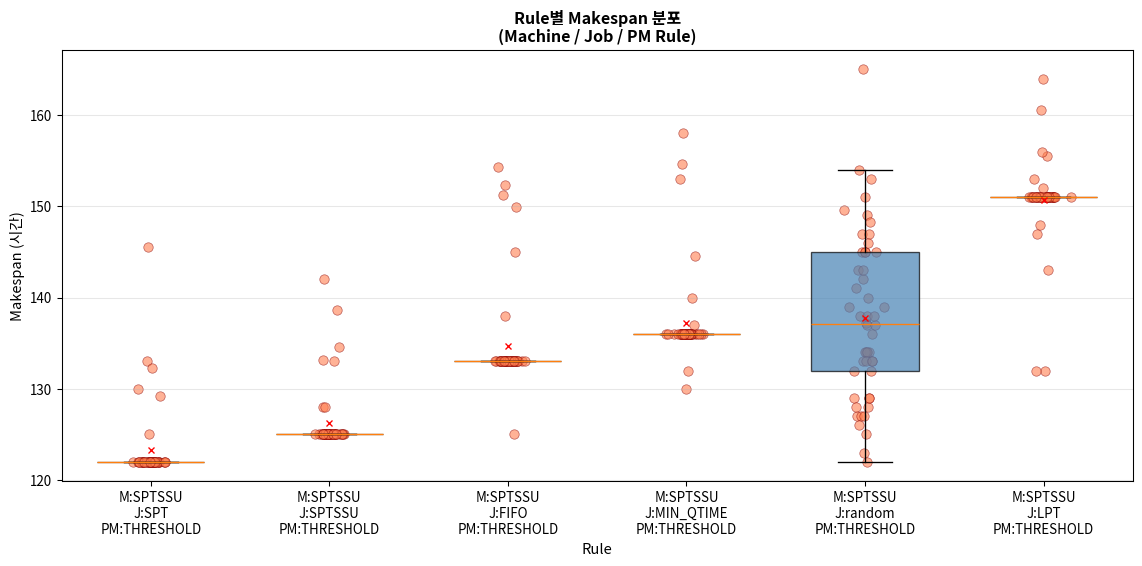

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

# Rule별로 그룹화하여 데이터 준비
makespan_grouped = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule'])
rule_indices = list(makespan_grouped.groups.keys())

# 평균값 계산하여 정렬
rule_avg_makespan = []
for idx in rule_indices:
    avg_makespan = metrics_df[
        (metrics_df['machine_rule'] == idx[0]) &
        (metrics_df['job_rule'] == idx[1]) &
        (metrics_df['pm_rule'] == idx[2])
    ]['makespan'].mean()
    rule_avg_makespan.append((idx, avg_makespan))

rule_avg_makespan.sort(key=lambda x: x[1])
rule_indices = [x[0] for x in rule_avg_makespan]
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices]

# Box plot 생성
box_data = [metrics_df[
    (metrics_df['machine_rule'] == idx[0]) &
    (metrics_df['job_rule'] == idx[1]) &
    (metrics_df['pm_rule'] == idx[2])
]['makespan'].values for idx in rule_indices]

bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

# Box plot 색상 설정
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

# Scatter plot 오버레이 (좌우로 scatter)
for i, data in enumerate(box_data):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    ax.scatter(x_jittered, data, alpha=0.6, s=50, color='coral', edgecolors='darkred', linewidth=0.5)
    # 평균을 X로 표시
    ax.plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='red', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('Makespan (시간)', fontsize=11)
ax.set_title('Rule별 Makespan 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Qtime Violation

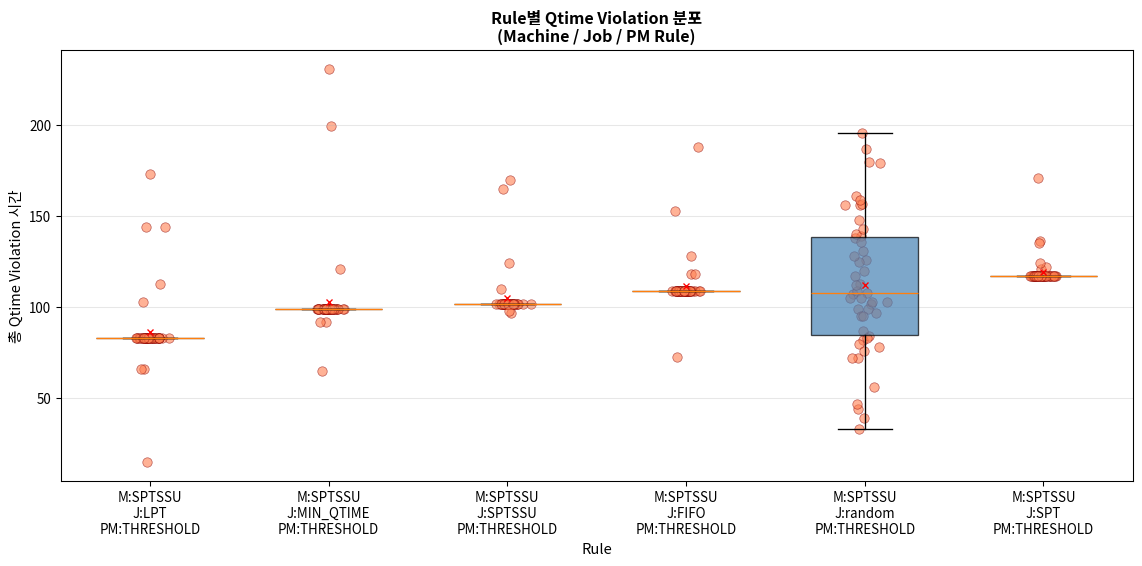

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Rule별로 그룹화하여 데이터 준비
qtime_grouped = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule'])
rule_indices = list(qtime_grouped.groups.keys())

# 평균값 계산하여 정렬
rule_avg_qtime = []
for idx in rule_indices:
    avg_qtime = metrics_df[
        (metrics_df['machine_rule'] == idx[0]) &
        (metrics_df['job_rule'] == idx[1]) &
        (metrics_df['pm_rule'] == idx[2])
    ]['qtime_violations'].mean()
    rule_avg_qtime.append((idx, avg_qtime))

rule_avg_qtime.sort(key=lambda x: x[1])
rule_indices = [x[0] for x in rule_avg_qtime]
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices]

# Box plot 생성
box_data = [metrics_df[
    (metrics_df['machine_rule'] == idx[0]) &
    (metrics_df['job_rule'] == idx[1]) &
    (metrics_df['pm_rule'] == idx[2])
]['qtime_violations'].values for idx in rule_indices]

bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

# Box plot 색상 설정
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

# Scatter plot 오버레이 (좌우로 scatter)
for i, data in enumerate(box_data):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    ax.scatter(x_jittered, data, alpha=0.6, s=50, color='coral', edgecolors='darkred', linewidth=0.5)
    # 평균을 X로 표시
    ax.plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='red', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('총 Qtime Violation 시간', fontsize=11)
ax.set_title('Rule별 Qtime Violation 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## PM & Repair

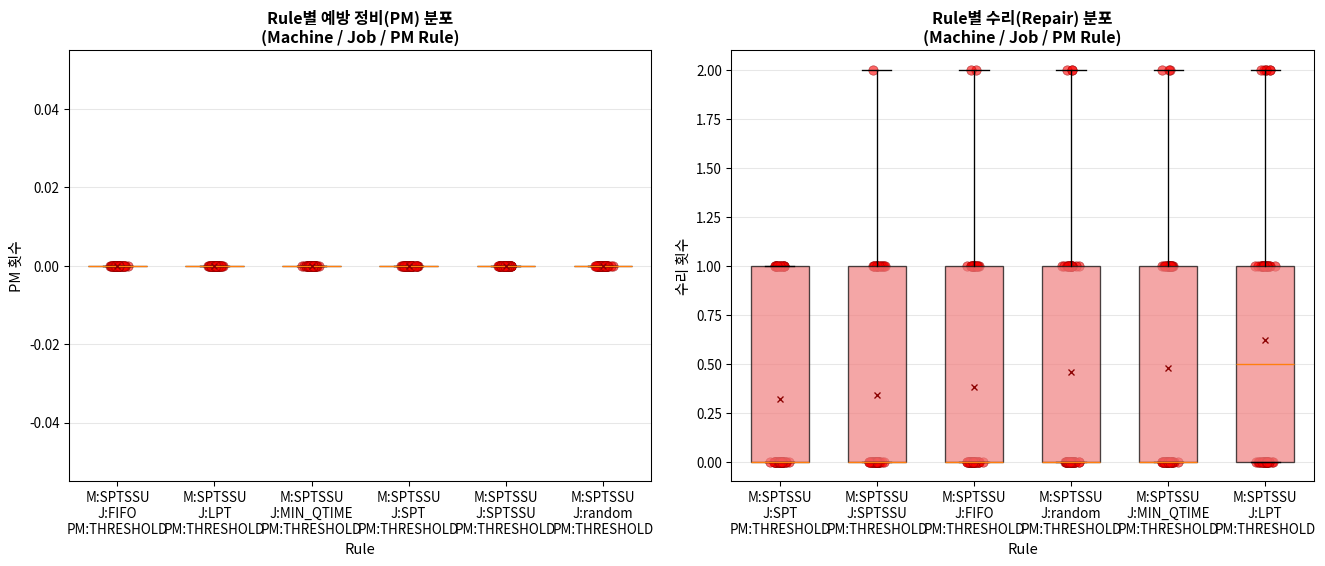

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PM 비교 (machine_rule, job_rule, pm_rule별로 그룹화)
pm_grouped = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule'])
rule_indices_pm_raw = list(pm_grouped.groups.keys())

# 평균 PM 값 계산하여 정렬
rule_avg_pm = []
for idx in rule_indices_pm_raw:
    avg_pm = metrics_df[
        (metrics_df['machine_rule'] == idx[0]) &
        (metrics_df['job_rule'] == idx[1]) &
        (metrics_df['pm_rule'] == idx[2])
    ]['n_pm'].mean()
    rule_avg_pm.append((idx, avg_pm))

rule_avg_pm.sort(key=lambda x: x[1])
rule_indices_pm = [x[0] for x in rule_avg_pm]
rule_labels_pm = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices_pm]

# PM Box plot 생성
box_data_pm = [metrics_df[
    (metrics_df['machine_rule'] == idx[0]) &
    (metrics_df['job_rule'] == idx[1]) &
    (metrics_df['pm_rule'] == idx[2])
]['n_pm'].values for idx in rule_indices_pm]

bp_pm = axes[0].boxplot(box_data_pm, labels=rule_labels_pm, patch_artist=True, widths=0.6, showfliers=False)

# PM Box plot 색상 설정
for patch in bp_pm['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)

# PM Scatter plot 오버레이
for i, data in enumerate(box_data_pm):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    axes[0].scatter(x_jittered, data, alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5)
    # 평균을 X로 표시
    axes[0].plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='darkred', zorder=3)

axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel('PM 횟수', fontsize=11)
axes[0].set_title('Rule별 예방 정비(PM) 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Repair 비교 (machine_rule, job_rule, pm_rule별로 그룹화)
repair_grouped = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule'])
rule_indices_repair_raw = list(repair_grouped.groups.keys())

# 평균 Repair 값 계산하여 정렬
rule_avg_repair = []
for idx in rule_indices_repair_raw:
    avg_repair = metrics_df[
        (metrics_df['machine_rule'] == idx[0]) &
        (metrics_df['job_rule'] == idx[1]) &
        (metrics_df['pm_rule'] == idx[2])
    ]['n_repairs'].mean()
    rule_avg_repair.append((idx, avg_repair))

rule_avg_repair.sort(key=lambda x: x[1])
rule_indices_repair = [x[0] for x in rule_avg_repair]
rule_labels_repair = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices_repair]

# Repair Box plot 생성
box_data_repair = [metrics_df[
    (metrics_df['machine_rule'] == idx[0]) &
    (metrics_df['job_rule'] == idx[1]) &
    (metrics_df['pm_rule'] == idx[2])
]['n_repairs'].values for idx in rule_indices_repair]

bp_repair = axes[1].boxplot(box_data_repair, labels=rule_labels_repair, patch_artist=True, widths=0.6, showfliers=False)

# Repair Box plot 색상 설정
for patch in bp_repair['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)

# Repair Scatter plot 오버레이
for i, data in enumerate(box_data_repair):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    axes[1].scatter(x_jittered, data, alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5)
    # 평균을 X로 표시
    axes[1].plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='darkred', zorder=3)

axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel('수리 횟수', fontsize=11)
axes[1].set_title('Rule별 수리(Repair) 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Utilization

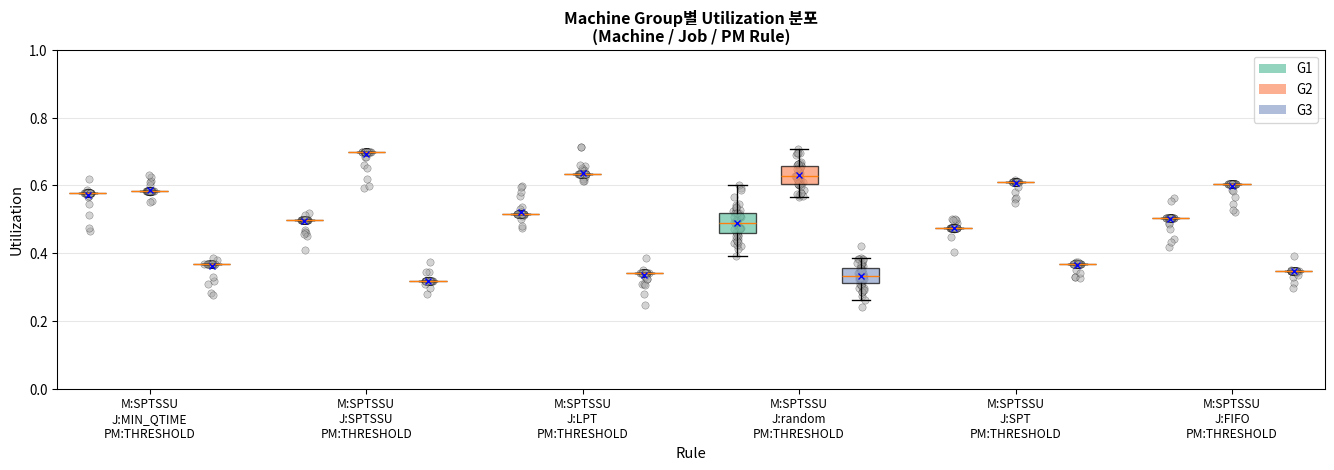

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Utilization by Machine Group
utilization_data = []
for idx, row in metrics_df.iterrows():
    for machine_group, util_val in row['utilization'].items():
        utilization_data.append({
            'machine_rule': row['machine_rule'],
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'machine_group': machine_group,
            'utilization': util_val
        })

utilization_df = pd.DataFrame(utilization_data)

# Machine group별 처리
machine_groups = sorted(utilization_df['machine_group'].unique())
rule_indices_raw = [(row[0], row[1], row[2]) for row in utilization_df[['machine_rule', 'job_rule', 'pm_rule']].drop_duplicates().values]

# 평균 utilization 계산하여 정렬
rule_avg_util = []
for rule_idx in rule_indices_raw:
    avg_util = utilization_df[
        (utilization_df['machine_rule'] == rule_idx[0]) &
        (utilization_df['job_rule'] == rule_idx[1]) &
        (utilization_df['pm_rule'] == rule_idx[2])
    ]['utilization'].mean()
    rule_avg_util.append((rule_idx, avg_util))

rule_avg_util.sort(key=lambda x: x[1], reverse=True)
rule_indices = [x[0] for x in rule_avg_util]
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices]

# Machine group별로 box plot 생성
for mg_idx, machine_group in enumerate(machine_groups):
    # 각 rule별로 해당 machine group의 데이터 추출
    box_data = []
    for rule_idx in rule_indices:
        data = utilization_df[
            (utilization_df['machine_rule'] == rule_idx[0]) &
            (utilization_df['job_rule'] == rule_idx[1]) &
            (utilization_df['pm_rule'] == rule_idx[2]) &
            (utilization_df['machine_group'] == machine_group)
        ]['utilization'].values
        box_data.append(data if len(data) > 0 else [0])
    
    # Box plot 생성 (offset 적용)
    positions = np.arange(len(rule_indices)) * (len(machine_groups) + 0.5) + mg_idx
    bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                    showfliers=False)
    
    # 색상 설정
    colors = plt.cm.Set2(range(len(machine_groups)))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[mg_idx])
        patch.set_alpha(0.7)
    
    # Scatter plot 오버레이
    for i, data in enumerate(box_data):
        if len(data) > 0 and data[0] != 0:
            x_pos = [positions[i]] * len(data)
            x_jittered = [x + np.random.normal(0, 0.03) for x in x_pos]
            ax.scatter(x_jittered, data, alpha=0.5, s=30, color='darkgray', edgecolors='black', linewidth=0.3)
            # 평균을 X로 표시
            ax.plot(positions[i], np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='blue', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('Utilization', fontsize=11)
ax.set_title('Machine Group별 Utilization 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
ax.set_xticks(np.arange(len(rule_indices)) * (len(machine_groups) + 0.5) + (len(machine_groups) - 1) / 2)
ax.set_xticklabels(rule_labels, fontsize=9)
ax.legend([plt.Rectangle((0, 0), 1, 1, fc=plt.cm.Set2(i), alpha=0.7) for i in range(len(machine_groups))],
          machine_groups, fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Flowtime & Tardiness

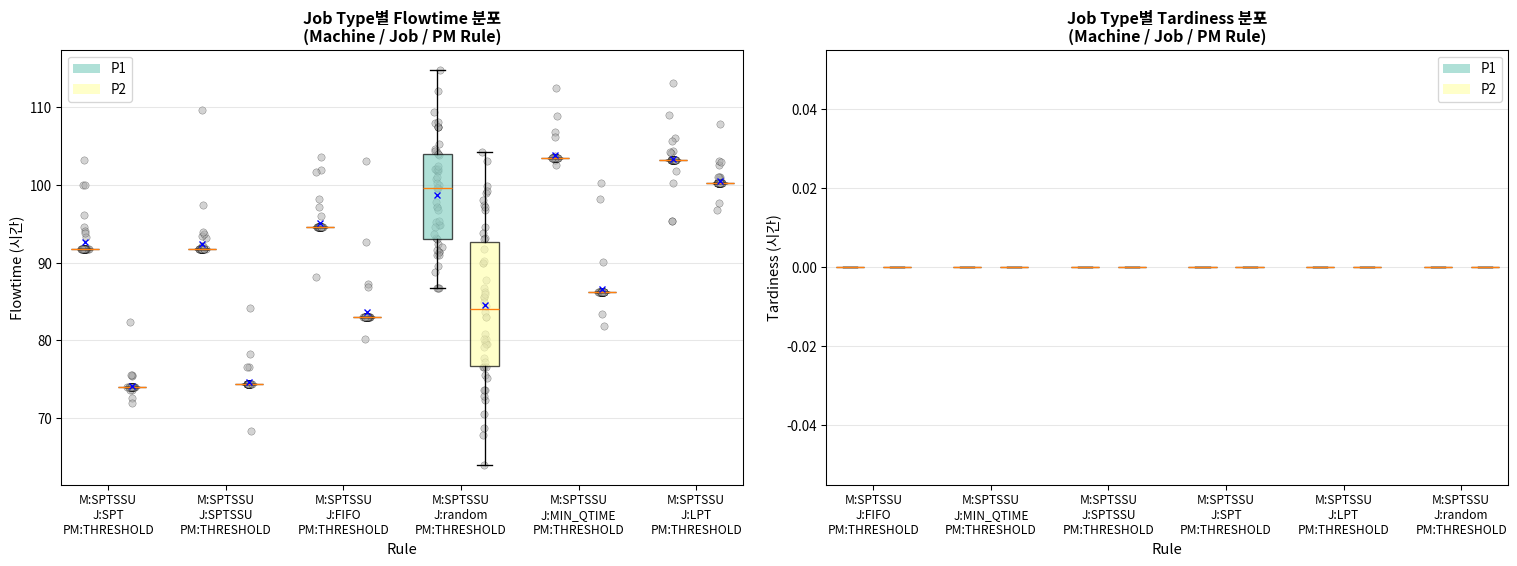

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flowtime by Job Type
flowtime_data = []
for idx, row in metrics_df.iterrows():
    for job_type, flowtime_val in row['flowtime'].items():
        flowtime_data.append({
            'machine_rule': row['machine_rule'],
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'job_type': job_type,
            'flowtime': flowtime_val
        })

flowtime_df = pd.DataFrame(flowtime_data)

# Job type별 처리
job_types = sorted(flowtime_df['job_type'].unique())
rule_indices_raw = [(row[0], row[1], row[2]) for row in flowtime_df[['machine_rule', 'job_rule', 'pm_rule']].drop_duplicates().values]

# 평균 flowtime 계산하여 정렬
rule_avg_flowtime = []
for rule_idx in rule_indices_raw:
    avg_flowtime = flowtime_df[
        (flowtime_df['machine_rule'] == rule_idx[0]) &
        (flowtime_df['job_rule'] == rule_idx[1]) &
        (flowtime_df['pm_rule'] == rule_idx[2])
    ]['flowtime'].mean()
    rule_avg_flowtime.append((rule_idx, avg_flowtime))

rule_avg_flowtime.sort(key=lambda x: x[1])
rule_indices = [x[0] for x in rule_avg_flowtime]
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices]

# Job type별로 box plot 생성
for job_type_idx, job_type in enumerate(job_types):
    # 각 rule별로 해당 job type의 데이터 추출
    box_data = []
    for rule_idx in rule_indices:
        data = flowtime_df[
            (flowtime_df['machine_rule'] == rule_idx[0]) &
            (flowtime_df['job_rule'] == rule_idx[1]) &
            (flowtime_df['pm_rule'] == rule_idx[2]) &
            (flowtime_df['job_type'] == job_type)
        ]['flowtime'].values
        box_data.append(data if len(data) > 0 else [0])
    
    # Box plot 생성 (offset 적용)
    positions = np.arange(len(rule_indices)) * (len(job_types) + 0.5) + job_type_idx
    bp = axes[0].boxplot(box_data, positions=positions, widths=0.6, patch_artist=True, 
                         showfliers=False)
    
    # 색상 설정
    colors = plt.cm.Set3(range(len(job_types)))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[job_type_idx])
        patch.set_alpha(0.7)
    
    # Scatter plot 오버레이
    for i, data in enumerate(box_data):
        if len(data) > 0 and data[0] != 0:
            x_pos = [positions[i]] * len(data)
            x_jittered = [x + np.random.normal(0, 0.03) for x in x_pos]
            axes[0].scatter(x_jittered, data, alpha=0.5, s=30, color='darkgray', edgecolors='black', linewidth=0.3)
            axes[0].plot(positions[i], np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='blue', zorder=5)

axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel('Flowtime (시간)', fontsize=11)
axes[0].set_title('Job Type별 Flowtime 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[0].set_xticks(np.arange(len(rule_indices)) * (len(job_types) + 0.5) + (len(job_types) - 1) / 2)
axes[0].set_xticklabels(rule_labels, fontsize=9)
axes[0].legend([plt.Rectangle((0, 0), 1, 1, fc=plt.cm.Set3(i), alpha=0.7) for i in range(len(job_types))], 
               job_types, fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Tardiness by Job Type
tardiness_data = []
for idx, row in metrics_df.iterrows():
    for job_type, tardiness_val in row['tardiness'].items():
        tardiness_data.append({
            'machine_rule': row['machine_rule'],
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'job_type': job_type,
            'tardiness': tardiness_val
        })

tardiness_df = pd.DataFrame(tardiness_data)

# Job type별 처리
job_types = sorted(tardiness_df['job_type'].unique())

# 평균 tardiness 계산하여 정렬
rule_avg_tardiness = []
for rule_idx in rule_indices_raw:
    avg_tardiness = tardiness_df[
        (tardiness_df['machine_rule'] == rule_idx[0]) &
        (tardiness_df['job_rule'] == rule_idx[1]) &
        (tardiness_df['pm_rule'] == rule_idx[2])
    ]['tardiness'].mean()
    rule_avg_tardiness.append((rule_idx, avg_tardiness))

rule_avg_tardiness.sort(key=lambda x: x[1])
rule_indices = [x[0] for x in rule_avg_tardiness]
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in rule_indices]

# Job type별로 box plot 생성
for job_type_idx, job_type in enumerate(job_types):
    # 각 rule별로 해당 job type의 데이터 추출
    box_data = []
    for rule_idx in rule_indices:
        data = tardiness_df[
            (tardiness_df['machine_rule'] == rule_idx[0]) &
            (tardiness_df['job_rule'] == rule_idx[1]) &
            (tardiness_df['pm_rule'] == rule_idx[2]) &
            (tardiness_df['job_type'] == job_type)
        ]['tardiness'].values
        box_data.append(data if len(data) > 0 else [0])
    
    # Box plot 생성 (offset 적용)
    positions = np.arange(len(rule_indices)) * (len(job_types) + 0.5) + job_type_idx
    bp = axes[1].boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                         showfliers=False)
    
    # 색상 설정
    colors = plt.cm.Set3(range(len(job_types)))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[job_type_idx])
        patch.set_alpha(0.7)
    
    # Scatter plot 오버레이
    for i, data in enumerate(box_data):
        if len(data) > 0 and data[0] != 0:
            x_pos = [positions[i]] * len(data)
            x_jittered = [x + np.random.normal(0, 0.03) for x in x_pos]
            axes[1].scatter(x_jittered, data, alpha=0.5, s=30, color='darkgray', edgecolors='black', linewidth=0.3)
            # 평균을 X로 표시
            axes[1].plot(positions[i], np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='blue', zorder=5)

axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel('Tardiness (시간)', fontsize=11)
axes[1].set_title('Job Type별 Tardiness 분포\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[1].set_xticks(np.arange(len(rule_indices)) * (len(job_types) + 0.5) + (len(job_types) - 1) / 2)
axes[1].set_xticklabels(rule_labels, fontsize=9)
axes[1].legend([plt.Rectangle((0, 0), 1, 1, fc=plt.cm.Set3(i), alpha=0.7) for i in range(len(job_types))],
               job_types, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()